<a href="https://colab.research.google.com/github/aabyyaann/Introduction-to-Machine-Learning-with-Python/blob/main/Chapter5_Model_Evaluation_and_Improvement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# %% [markdown]
# # Chapter 5 - Model Evaluation and Improvement
#
# Notebook ini merangkum dan mereproduksi konsep penting pada Chapter 5 dari buku
# **Introduction to Machine Learning with Python**.
#
# Topik utama:
# 1. Cross-validation
# 2. Grid Search
# 3. Evaluation metrics untuk classification
# 4. Confusion matrix
# 5. Precision, Recall, F1-score
# 6. ROC Curve dan AUC
# 7. Evaluation untuk multiclass classification
# 8. Evaluation untuk regression
#
# Tujuan chapter ini adalah memahami bahwa **akurasi saja tidak selalu cukup**
# untuk mengevaluasi model machine learning. Kita perlu menggunakan metode evaluasi
# yang sesuai dengan jenis masalah dan tujuan bisnis/analisis.

# %% [markdown]
# ## 1. Import Library
#
# Pada chapter ini kita akan memakai:
# - `scikit-learn` untuk model, evaluasi, cross-validation, dan grid search
# - `matplotlib` untuk visualisasi
# - dataset bawaan seperti iris, breast cancer, dan boston-like synthetic regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, load_breast_cancer, make_blobs, make_regression
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold,
    StratifiedKFold,
    GridSearchCV
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier, DummyRegressor

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

print("Library Chapter 5 berhasil diimport.")

Library Chapter 5 berhasil diimport.


# %% [markdown]
# ## 2. Why Model Evaluation Matters
#
# Pada chapter sebelumnya kita sudah melatih model dan melihat akurasi train/test.
# Namun dalam praktik, evaluasi model tidak boleh hanya mengandalkan **satu kali split data**.
#
# Alasan:
# - Hasil train/test split bisa berubah tergantung pembagian data
# - Akurasi saja bisa menyesatkan pada data tidak seimbang
# - Kita perlu metode evaluasi yang lebih stabil
#
# Oleh karena itu, chapter ini memperkenalkan:
# - **Cross-validation** → evaluasi lebih stabil
# - **Grid search** → mencari hyperparameter terbaik
# - **Metrics khusus** → untuk klasifikasi tidak seimbang, multiclass, dan regresi

# %% [markdown]
# ## 3. Load Dataset untuk Klasifikasi
#
# Kita akan menggunakan dataset **Breast Cancer Wisconsin** dari scikit-learn.
# Tugasnya adalah mengklasifikasikan tumor menjadi:
# - malignant (ganas)
# - benign (jinak)
#
# Dataset ini sering dipakai di buku untuk menjelaskan evaluasi model klasifikasi.

In [2]:
cancer = load_breast_cancer()

X = cancer.data
y = cancer.target

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("Target names:", cancer.target_names)

df_cancer = pd.DataFrame(X, columns=cancer.feature_names)
df_cancer["target"] = y
display(df_cancer.head())

Shape X: (569, 30)
Shape y: (569,)
Target names: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


# %% [markdown]
# ## 4. Train-Test Split
#
# Pertama kita buat pembagian data train dan test.
# Ini adalah evaluasi paling dasar:
# - model dilatih di data train
# - model diuji di data test
#
# Namun nanti kita akan lihat bahwa **cross-validation** memberikan evaluasi yang lebih baik.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (426, 30)
X_test : (143, 30)


# %% [markdown]
# ## 5. Baseline Evaluation dengan Train/Test Split
#
# Kita mulai dengan model sederhana: **Logistic Regression**.
# Logistic Regression cocok untuk binary classification dan sering menjadi baseline yang kuat.

In [4]:
logreg = LogisticRegression(max_iter=10000)
logreg.fit(X_train, y_train)

train_score = logreg.score(X_train, y_train)
test_score = logreg.score(X_test, y_test)

print("Logistic Regression")
print(f"Training accuracy: {train_score:.4f}")
print(f"Test accuracy    : {test_score:.4f}")

Logistic Regression
Training accuracy: 0.9577
Test accuracy    : 0.9580


# %% [markdown]
# ## 6. Cross-Validation
#
# **Cross-validation** adalah teknik evaluasi yang membagi data menjadi beberapa bagian (fold).
# Model dilatih beberapa kali, dan setiap fold bergantian menjadi data validasi.
#
# Keuntungan cross-validation:
# - evaluasi lebih stabil daripada satu kali train/test split
# - memanfaatkan data secara lebih efisien
# - memberi gambaran performa model yang lebih umum
#
# Bentuk paling umum adalah **k-fold cross-validation**.

In [5]:
scores = cross_val_score(LogisticRegression(max_iter=10000), X, y, cv=5)

print("Cross-validation scores:", scores)
print("Mean CV score         :", scores.mean())
print("Std CV score          :", scores.std())

Cross-validation scores: [0.93859649 0.94736842 0.98245614 0.92982456 0.95575221]
Mean CV score         : 0.9507995652848935
Std CV score          : 0.01804054330253301


# %% [markdown]
# ## 7. Interpretasi Cross-Validation
#
# Dari hasil cross-validation, kita tidak hanya melihat **satu angka akurasi**,
# tetapi beberapa skor dari fold yang berbeda.
#
# Hal yang diperhatikan:
# - **Mean CV score** → performa rata-rata model
# - **Std CV score** → kestabilan model antar fold
#
# Jika standar deviasi kecil, performa model cenderung stabil.
# Jika standar deviasi besar, performa model sensitif terhadap pembagian data.

# %% [markdown]
# ## 8. Comparing Models with Cross-Validation
#
# Sekarang kita bandingkan beberapa model:
# - Logistic Regression
# - KNeighborsClassifier
# - Decision Tree
#
# Tujuannya adalah melihat bahwa cross-validation bisa dipakai untuk membandingkan model
# secara lebih adil daripada hanya satu train/test split.

In [6]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=10000),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5)
    cv_results[name] = scores
    print(f"{name}")
    print("  CV scores:", np.round(scores, 4))
    print(f"  Mean CV : {scores.mean():.4f}")
    print(f"  Std CV  : {scores.std():.4f}\n")

Logistic Regression
  CV scores: [0.9386 0.9474 0.9825 0.9298 0.9558]
  Mean CV : 0.9508
  Std CV  : 0.0180

KNN (k=5)
  CV scores: [0.886  0.9386 0.9386 0.9474 0.9292]
  Mean CV : 0.9279
  Std CV  : 0.0218

Decision Tree
  CV scores: [0.9123 0.9035 0.9298 0.9561 0.885 ]
  Mean CV : 0.9173
  Std CV  : 0.0242



,Logistic Regression,KNN (k=5),Decision Tree
0,0.938596,0.885965,0.912281
1,0.947368,0.938596,0.903509
2,0.982456,0.938596,0.929825
3,0.929825,0.947368,0.956140
4,0.955752,0.929204,0.884956


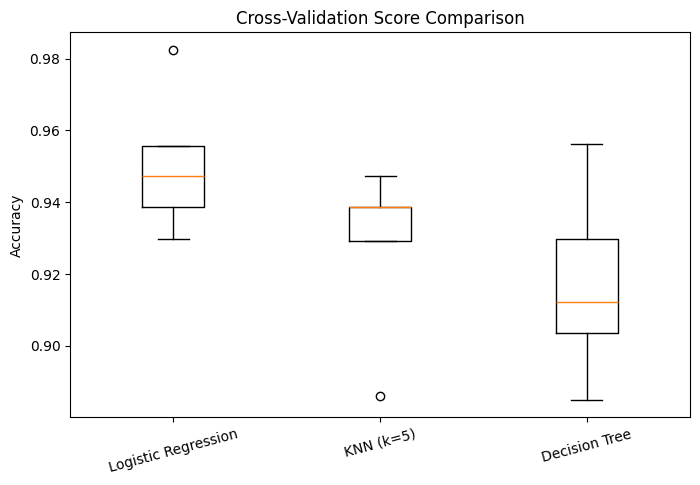

In [7]:
cv_df = pd.DataFrame({
    name: scores for name, scores in cv_results.items()
})

display(cv_df)

plt.figure(figsize=(8, 5))
plt.boxplot(cv_df.values, tick_labels=cv_df.columns)
plt.ylabel("Accuracy")
plt.title("Cross-Validation Score Comparison")
plt.xticks(rotation=15)
plt.show()

# %% [markdown]
# ## 9. KFold and StratifiedKFold
#
# Secara default:
# - untuk klasifikasi, scikit-learn biasanya memakai **StratifiedKFold**
# - untuk regresi, biasanya memakai **KFold**
#
# **StratifiedKFold** menjaga proporsi kelas di setiap fold agar mirip dengan dataset asli.
# Ini penting pada klasifikasi, terutama jika data tidak seimbang.

In [8]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
strat_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_kfold = cross_val_score(LogisticRegression(max_iter=10000), X, y, cv=kfold)
scores_strat = cross_val_score(LogisticRegression(max_iter=10000), X, y, cv=strat_kfold)

print("KFold CV scores           :", np.round(scores_kfold, 4))
print("KFold mean                :", scores_kfold.mean())
print()
print("StratifiedKFold CV scores :", np.round(scores_strat, 4))
print("StratifiedKFold mean      :", scores_strat.mean())

KFold CV scores           : [0.9561 0.9649 0.9386 0.9737 0.9204]
KFold mean                : 0.9507374631268437

StratifiedKFold CV scores : [0.9649 0.9211 0.9649 0.9474 0.9735]
StratifiedKFold mean      : 0.9543393882937432


# %% [markdown]
# ## 10. Grid Search
#
# Setelah kita punya metode evaluasi yang baik, langkah berikutnya adalah memilih
# **hyperparameter** terbaik.
#
# Contoh:
# - pada SVM, parameter penting adalah `C` dan `gamma`
# - pada KNN, parameter penting adalah `n_neighbors`
# - pada Decision Tree, parameter penting misalnya `max_depth`
#
# **Grid Search** mencoba beberapa kombinasi hyperparameter, lalu mengevaluasinya
# menggunakan cross-validation.

# %% [markdown]
# ## 11. Example Grid Search with SVC
#
# Kita akan menggunakan model **Support Vector Classifier (SVC)** dan mencoba beberapa
# kombinasi hyperparameter:
# - `C`
# - `gamma`
#
# Tujuannya adalah mencari kombinasi parameter yang menghasilkan performa terbaik.

In [9]:
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": [0.001, 0.01, 0.1, 1]
}

grid_search = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV score  :", grid_search.best_score_)

Best parameters: {'C': 1, 'gamma': 0.001}
Best CV score  : 0.9271682626538988


# %% [markdown]
# ## 12. Best Estimator from Grid Search
#
# Setelah grid search selesai, kita bisa mengambil model terbaik melalui:
# - `best_params_`
# - `best_score_`
# - `best_estimator_`
#
# Model terbaik ini sudah dilatih menggunakan kombinasi hyperparameter terbaik
# pada data training.

In [10]:
best_model = grid_search.best_estimator_

test_score = best_model.score(X_test, y_test)

print("Best estimator:", best_model)
print(f"Test accuracy with best model: {test_score:.4f}")

Best estimator: SVC(C=1, gamma=0.001)
Test accuracy with best model: 0.9021


# %% [markdown]
# ## 13. Grid Search Results Table
#
# Semua hasil grid search bisa dilihat dalam bentuk tabel menggunakan `cv_results_`.
# Ini membantu kita memahami:
# - kombinasi parameter mana yang dicoba
# - mean test score tiap kombinasi
# - ranking performa

In [11]:
results = pd.DataFrame(grid_search.cv_results_)

cols_to_show = [
    "param_C",
    "param_gamma",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]

display(results[cols_to_show].sort_values("rank_test_score").head(10))

,param_C,param_gamma,mean_test_score,std_test_score,rank_test_score
4,1.0,0.001,0.927168,0.026310,1
8,10.0,0.001,0.901477,0.021403,2
12,100.0,0.001,0.901477,0.021403,2
13,100.0,0.010,0.629111,0.005296,4
9,10.0,0.010,0.629111,0.005296,4
0,0.1,0.001,0.626758,0.004593,6
2,0.1,0.100,0.626758,0.004593,6
1,0.1,0.010,0.626758,0.004593,6
11,10.0,1.000,0.626758,0.004593,6
7,1.0,1.000,0.626758,0.004593,6


# %% [markdown]
# ## 14. Heatmap of Grid Search Results
#
# Agar lebih mudah dibaca, kita visualisasikan hasil grid search ke dalam heatmap.
# Ini memperlihatkan bagaimana kombinasi `C` dan `gamma` memengaruhi akurasi.

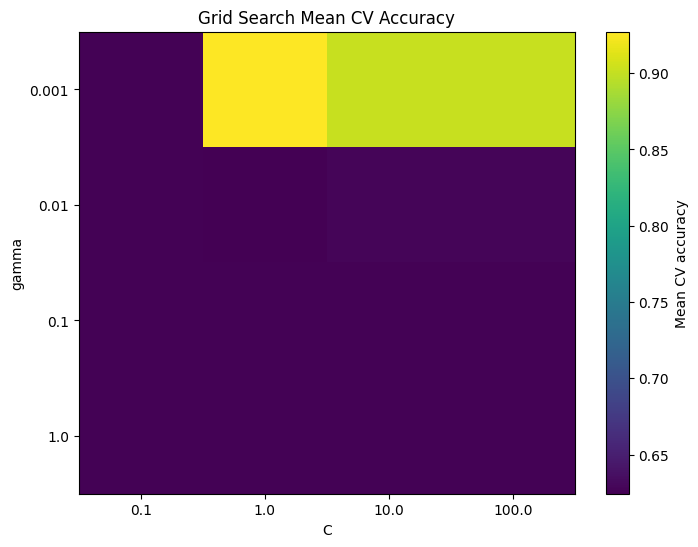

param_C,0.1,1.0,10.0,100.0
param_gamma,,,,
0.001,0.626758,0.927168,0.901477,0.901477
0.010,0.626758,0.624405,0.629111,0.629111
0.100,0.626758,0.626758,0.626758,0.626758
1.000,0.626758,0.626758,0.626758,0.626758


In [12]:
scores_matrix = results.pivot(index="param_gamma", columns="param_C", values="mean_test_score")

plt.figure(figsize=(8, 6))
plt.imshow(scores_matrix, cmap="viridis", aspect="auto")
plt.colorbar(label="Mean CV accuracy")
plt.xticks(range(len(scores_matrix.columns)), scores_matrix.columns)
plt.yticks(range(len(scores_matrix.index)), scores_matrix.index)
plt.xlabel("C")
plt.ylabel("gamma")
plt.title("Grid Search Mean CV Accuracy")
plt.show()

display(scores_matrix)

# %% [markdown]
# ## 15. Why Accuracy Is Not Always Enough
#
# Accuracy menghitung proporsi prediksi yang benar secara keseluruhan.
#
# Rumus:
#
# `Accuracy = (jumlah prediksi benar) / (total prediksi)`
#
# Masalahnya:
# jika dataset **tidak seimbang**, accuracy bisa tampak tinggi walaupun model sebenarnya buruk.
#
# Contoh:
# - 95% data = kelas negatif
# - 5% data = kelas positif
# - model selalu menebak "negatif"
#
# Maka accuracy = 95%, padahal model **gagal total mendeteksi kelas positif**.

# %% [markdown]
# ## 16. Dummy Classifier as a Baseline
#
# Untuk menunjukkan keterbatasan accuracy, kita buat contoh baseline dengan
# **DummyClassifier**, yaitu model yang sangat sederhana dan tidak benar-benar belajar
# pola dari data.
#
# Kita akan membandingkan:
# - DummyClassifier
# - Logistic Regression

In [13]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

logreg = LogisticRegression(max_iter=10000)
logreg.fit(X_train, y_train)
logreg_pred = logreg.predict(X_test)

print("Dummy Accuracy      :", accuracy_score(y_test, dummy_pred))
print("Logistic Accuracy   :", accuracy_score(y_test, logreg_pred))

Dummy Accuracy      : 0.6293706293706294
Logistic Accuracy   : 0.958041958041958


# %% [markdown]
# ## 17. Confusion Matrix
#
# **Confusion matrix** memberikan informasi yang lebih detail dibanding accuracy.
#
# Untuk binary classification:
#
# - **True Positive (TP)**  → positif diprediksi positif
# - **True Negative (TN)**  → negatif diprediksi negatif
# - **False Positive (FP)** → negatif diprediksi positif
# - **False Negative (FN)** → positif diprediksi negatif
#
# Dari confusion matrix, kita bisa menghitung precision, recall, dan F1-score.

In [14]:
cm = confusion_matrix(y_test, logreg_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[48  5]
 [ 1 89]]


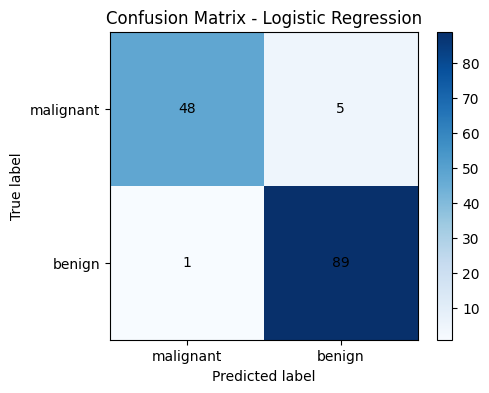

In [15]:
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks([0, 1], cancer.target_names)
plt.yticks([0, 1], cancer.target_names)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - Logistic Regression")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.show()

# %% [markdown]
# ## 18. Precision, Recall, and F1-score
#
# Untuk masalah klasifikasi, terutama data tidak seimbang, kita sering memakai:
#
# ### Precision
# Dari semua prediksi positif, berapa yang benar-benar positif?
#
# `Precision = TP / (TP + FP)`
#
# Precision tinggi berarti model jarang memberi alarm positif palsu.
#
# ---
#
# ### Recall
# Dari semua data yang benar-benar positif, berapa yang berhasil ditemukan model?
#
# `Recall = TP / (TP + FN)`
#
# Recall tinggi berarti model jarang melewatkan kasus positif.
#
# ---
#
# ### F1-score
# Rata-rata harmonik precision dan recall.
#
# `F1 = 2 * (precision * recall) / (precision + recall)`
#
# F1 cocok saat kita ingin menyeimbangkan precision dan recall.

In [16]:
precision = precision_score(y_test, logreg_pred)
recall = recall_score(y_test, logreg_pred)
f1 = f1_score(y_test, logreg_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Precision: 0.9468
Recall   : 0.9889
F1-score : 0.9674


In [17]:
print("Classification Report:\n")
print(classification_report(y_test, logreg_pred, target_names=cancer.target_names))

Classification Report:

              precision    recall  f1-score   support

   malignant       0.98      0.91      0.94        53
      benign       0.95      0.99      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143



# %% [markdown]
# ## 19. Precision vs Recall Trade-off
#
# Dalam banyak kasus, precision dan recall saling trade-off.
#
# Contoh:
# - Jika threshold model dibuat lebih ketat, precision bisa naik tapi recall turun
# - Jika threshold dibuat lebih longgar, recall bisa naik tapi precision turun
#
# Pemilihan metric tergantung konteks:
#
# ### Jika recall lebih penting:
# - deteksi penyakit
# - fraud detection
# - spam berbahaya
#
# ### Jika precision lebih penting:
# - sistem rekomendasi tindakan mahal
# - prediksi yang jika salah akan merugikan pengguna

# %% [markdown]
# ## 20. Decision Function / Predicted Probabilities
#
# Banyak model tidak hanya memberi label prediksi, tetapi juga skor keyakinan:
# - `predict_proba()` → probabilitas tiap kelas
# - `decision_function()` → skor keputusan
#
# Skor ini berguna untuk:
# - mengubah threshold klasifikasi
# - membuat ROC curve
# - membuat precision-recall curve

In [18]:
logreg = LogisticRegression(max_iter=10000)
logreg.fit(X_train, y_train)

y_prob = logreg.predict_proba(X_test)[:, 1]

print("5 probabilitas pertama:")
print(y_prob[:5])

5 probabilitas pertama:
[0.98145302 0.00183139 0.82283643 0.7655259  0.80203399]


# %% [markdown]
# ## 21. Threshold Tuning Example
#
# Secara default, model biasanya memakai threshold 0.5:
# - jika probabilitas >= 0.5 → kelas positif
# - jika probabilitas < 0.5  → kelas negatif
#
# Kita bisa mengubah threshold untuk melihat trade-off precision dan recall.

In [19]:
threshold = 0.3
y_pred_03 = (y_prob >= threshold).astype(int)

print(f"Threshold = {threshold}")
print("Precision:", precision_score(y_test, y_pred_03))
print("Recall   :", recall_score(y_test, y_pred_03))
print("F1-score :", f1_score(y_test, y_pred_03))

Threshold = 0.3
Precision: 0.9270833333333334
Recall   : 0.9888888888888889
F1-score : 0.956989247311828


In [20]:
threshold = 0.7
y_pred_07 = (y_prob >= threshold).astype(int)

print(f"Threshold = {threshold}")
print("Precision:", precision_score(y_test, y_pred_07))
print("Recall   :", recall_score(y_test, y_pred_07))
print("F1-score :", f1_score(y_test, y_pred_07))

Threshold = 0.7
Precision: 0.9555555555555556
Recall   : 0.9555555555555556
F1-score : 0.9555555555555556


# %% [markdown]
# ## 22. ROC Curve
#
# **ROC (Receiver Operating Characteristic) curve** menunjukkan hubungan antara:
# - **True Positive Rate (Recall)**
# - **False Positive Rate**
#
# ROC curve dibuat dengan mencoba banyak threshold yang berbeda.
#
# Semakin dekat kurva ke kiri-atas, semakin baik model.

In [21]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print("ROC AUC:", roc_auc)

ROC AUC: 0.9955974842767296


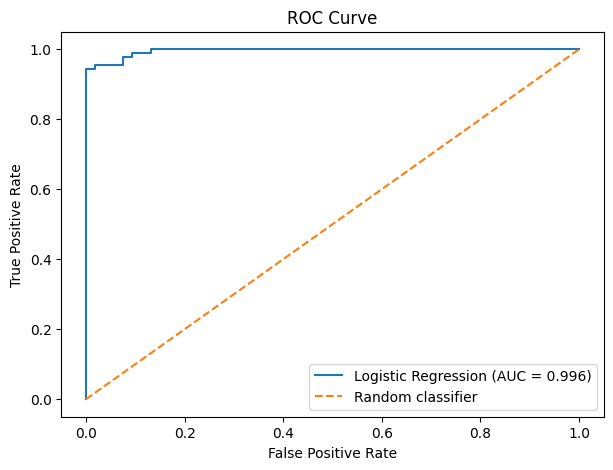

In [22]:
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# %% [markdown]
# ## 23. Interpreting ROC AUC
#
# **AUC (Area Under the Curve)** merangkum ROC curve menjadi satu angka.
#
# Interpretasi umum:
# - **AUC = 0.5** → setara tebakan acak
# - **AUC mendekati 1.0** → model sangat baik
#
# ROC AUC berguna untuk mengukur kemampuan model membedakan kelas positif dan negatif
# pada berbagai threshold.

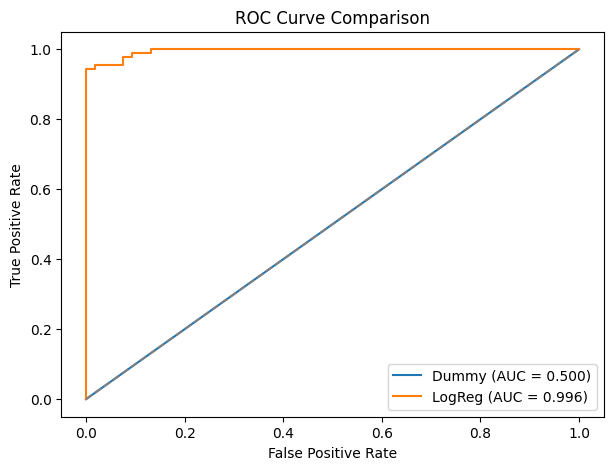

In [23]:
dummy_prob = np.zeros_like(y_test, dtype=float)

fpr_dummy, tpr_dummy, _ = roc_curve(y_test, dummy_prob)
dummy_auc = auc(fpr_dummy, tpr_dummy)

plt.figure(figsize=(7, 5))
plt.plot(fpr_dummy, tpr_dummy, label=f"Dummy (AUC = {dummy_auc:.3f})")
plt.plot(fpr, tpr, label=f"LogReg (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# %% [markdown]
# ## 24. Precision-Recall Curve
#
# Pada data yang tidak seimbang, **precision-recall curve** sering lebih informatif
# daripada ROC curve.
#
# Alasannya:
# - ROC bisa terlihat bagus walaupun kelas positif sangat sedikit
# - Precision-recall lebih fokus pada performa terhadap kelas positif
#
# Ini penting untuk kasus seperti:
# - fraud detection
# - deteksi penyakit langka
# - anomaly detection

In [24]:
precisions, recalls, thresholds_pr = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)

print("Average Precision:", ap)

Average Precision: 0.9975079444942833


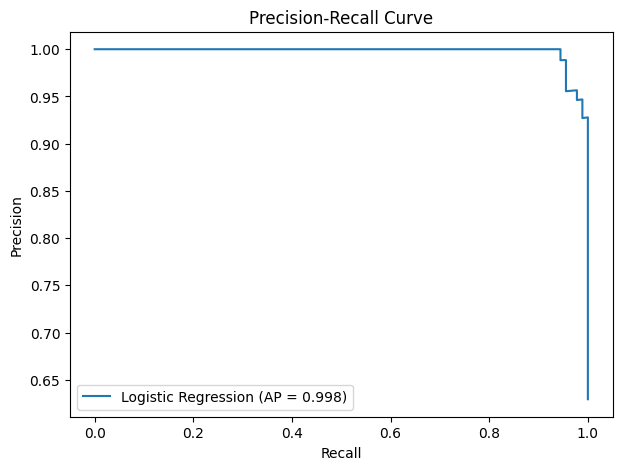

In [25]:
plt.figure(figsize=(7, 5))
plt.plot(recalls, precisions, label=f"Logistic Regression (AP = {ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

# %% [markdown]
# ## 25. Multiclass Classification Evaluation
#
# Sekarang kita beralih ke **multiclass classification** menggunakan dataset Iris.
#
# Pada multiclass classification, confusion matrix dan classification report tetap bisa dipakai.
# Namun precision, recall, dan F1-score akan dihitung **per kelas**.

In [26]:
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_iris, y_iris, stratify=y_iris, random_state=42
)

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_i, y_train_i)
y_pred_i = knn.predict(X_test_i)

print("Accuracy:", accuracy_score(y_test_i, y_pred_i))
print()
print(classification_report(y_test_i, y_pred_i, target_names=iris.target_names))

Accuracy: 0.9736842105263158

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.93      1.00      0.96        13
   virginica       1.00      0.92      0.96        13

    accuracy                           0.97        38
   macro avg       0.98      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38



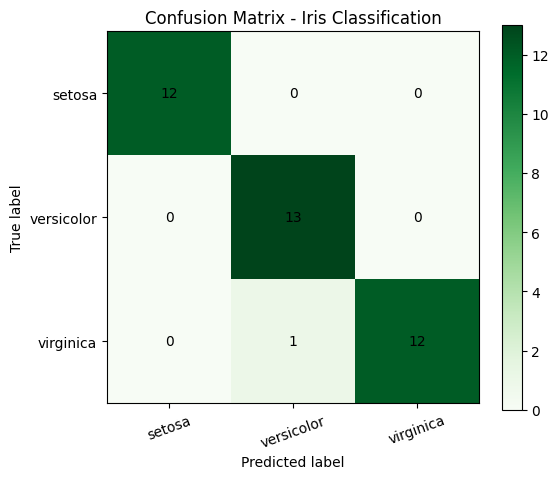

In [27]:
cm_iris = confusion_matrix(y_test_i, y_pred_i)

plt.figure(figsize=(6, 5))
plt.imshow(cm_iris, cmap="Greens")
plt.colorbar()
plt.xticks(range(len(iris.target_names)), iris.target_names, rotation=20)
plt.yticks(range(len(iris.target_names)), iris.target_names)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - Iris Classification")

for i in range(cm_iris.shape[0]):
    for j in range(cm_iris.shape[1]):
        plt.text(j, i, cm_iris[i, j], ha="center", va="center", color="black")

plt.show()

# %% [markdown]
# ## 26. Macro, Weighted, and Micro Average
#
# Pada multiclass classification, metrik seperti precision/recall/F1 dapat dirata-ratakan
# dengan beberapa cara:
#
# ### Macro Average
# Menghitung metric untuk tiap kelas, lalu dirata-ratakan tanpa memperhatikan jumlah data tiap kelas.
#
# ### Weighted Average
# Menghitung metric tiap kelas, lalu dirata-ratakan dengan bobot sesuai jumlah data per kelas.
#
# ### Micro Average
# Menggabungkan semua prediksi dari semua kelas terlebih dahulu, lalu menghitung metric global.
#
# Pilihan average bergantung pada tujuan evaluasi dan keseimbangan kelas.

In [28]:
print("F1 Macro   :", f1_score(y_test_i, y_pred_i, average="macro"))
print("F1 Weighted:", f1_score(y_test_i, y_pred_i, average="weighted"))
print("F1 Micro   :", f1_score(y_test_i, y_pred_i, average="micro"))

F1 Macro   : 0.974320987654321
F1 Weighted: 0.9736452241715401
F1 Micro   : 0.9736842105263158


# %% [markdown]
# ## 27. Regression Evaluation
#
# Selain classification, chapter ini juga membahas evaluasi untuk **regression**.
#
# Metric yang umum:
# - **R² score**
# - **Mean Squared Error (MSE)**
# - **Root Mean Squared Error (RMSE)**
# - **Mean Absolute Error (MAE)**
#
# Kita akan membuat contoh dataset regresi sintetis.

In [29]:
X_reg, y_reg = make_regression(
    n_samples=300,
    n_features=10,
    noise=15,
    random_state=42
)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, random_state=42
)

print("Train shape:", X_train_r.shape)
print("Test shape :", X_test_r.shape)

Train shape: (225, 10)
Test shape : (75, 10)


# %% [markdown]
# ## 28. Linear Regression and Ridge Regression
#
# Kita akan membandingkan dua model regresi:
# - **Linear Regression**
# - **Ridge Regression**
#
# Tujuannya adalah melihat performa model dengan metric regresi.

In [30]:
linreg = LinearRegression()
linreg.fit(X_train_r, y_train_r)
pred_lin = linreg.predict(X_test_r)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_r, y_train_r)
pred_ridge = ridge.predict(X_test_r)

In [31]:
def regression_metrics(y_true, y_pred, model_name="Model"):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(model_name)
    print(f"  MSE : {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE : {mae:.4f}")
    print(f"  R2  : {r2:.4f}")
    print()

regression_metrics(y_test_r, pred_lin, "Linear Regression")
regression_metrics(y_test_r, pred_ridge, "Ridge Regression")

Linear Regression
  MSE : 226.2831
  RMSE: 15.0427
  MAE : 12.3408
  R2  : 0.9930

Ridge Regression
  MSE : 228.2624
  RMSE: 15.1084
  MAE : 12.4094
  R2  : 0.9930



# %% [markdown]
# ## 29. Interpreting Regression Metrics
#
# ### MSE (Mean Squared Error)
# Mengukur rata-rata kuadrat error prediksi.
# Semakin kecil semakin baik, tetapi sensitif terhadap outlier.
#
# ### RMSE (Root Mean Squared Error)
# Akar dari MSE, sehingga satuannya sama dengan target.
#
# ### MAE (Mean Absolute Error)
# Rata-rata nilai absolut error.
# Lebih mudah diinterpretasikan dibanding MSE.
#
# ### R² Score
# Mengukur seberapa baik model menjelaskan variasi target.
#
# Interpretasi umum:
# - R² mendekati 1 → model bagus
# - R² mendekati 0 → model lemah
# - R² negatif → model sangat buruk

In [32]:
results_reg = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "MSE": [
        mean_squared_error(y_test_r, pred_lin),
        mean_squared_error(y_test_r, pred_ridge)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test_r, pred_lin)),
        np.sqrt(mean_squared_error(y_test_r, pred_ridge))
    ],
    "MAE": [
        mean_absolute_error(y_test_r, pred_lin),
        mean_absolute_error(y_test_r, pred_ridge)
    ],
    "R2": [
        r2_score(y_test_r, pred_lin),
        r2_score(y_test_r, pred_ridge)
    ]
})

display(results_reg)

,Model,MSE,RMSE,MAE,R2
0,Linear Regression,226.283103,15.042709,12.340799,0.993049
1,Ridge Regression,228.262412,15.108356,12.409449,0.992988


# %% [markdown]
# ## 30. Dummy Regressor as Baseline
#
# Sama seperti klasifikasi, regresi juga sebaiknya dibandingkan dengan baseline sederhana.
# Salah satu baseline adalah **DummyRegressor**, misalnya selalu memprediksi rata-rata target.
#
# Jika model regresi kita tidak jauh lebih baik dari baseline ini, berarti model belum benar-benar belajar pola yang berguna.

In [33]:
dummy_reg = DummyRegressor(strategy="mean")
dummy_reg.fit(X_train_r, y_train_r)
pred_dummy = dummy_reg.predict(X_test_r)

regression_metrics(y_test_r, pred_dummy, "Dummy Regressor")

Dummy Regressor
  MSE : 33162.0013
  RMSE: 182.1044
  MAE : 127.7706
  R2  : -0.0187



# %% [markdown]
# ## 31. Visualizing Regression Predictions
#
# Visualisasi actual vs predicted membantu melihat:
# - apakah prediksi mengikuti pola target
# - apakah ada bias sistematis
# - apakah error membesar pada rentang tertentu

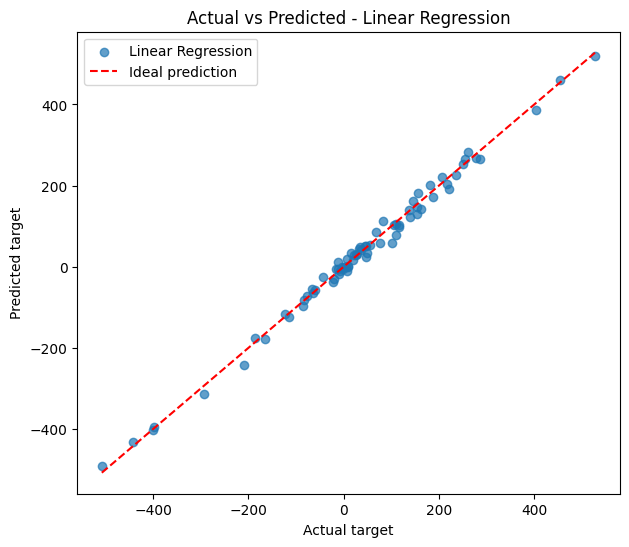

In [34]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test_r, pred_lin, alpha=0.7, label="Linear Regression")
plt.plot(
    [y_test_r.min(), y_test_r.max()],
    [y_test_r.min(), y_test_r.max()],
    "--",
    color="red",
    label="Ideal prediction"
)
plt.xlabel("Actual target")
plt.ylabel("Predicted target")
plt.title("Actual vs Predicted - Linear Regression")
plt.legend()
plt.show()

# %% [markdown]
# ## 32. Summary of Chapter 5
#
# Chapter 5 menekankan bahwa membangun model saja tidak cukup.
# Kita harus mengevaluasi model dengan metode dan metrik yang tepat.
#
# Ringkasan inti chapter:
#
# ### 1. Cross-validation
# Digunakan untuk evaluasi yang lebih stabil dibanding satu train/test split.
#
# ### 2. Grid Search
# Digunakan untuk mencari hyperparameter terbaik dengan bantuan cross-validation.
#
# ### 3. Accuracy tidak selalu cukup
# Terutama pada data yang tidak seimbang.
#
# ### 4. Confusion Matrix
# Memberikan gambaran detail jenis kesalahan model.
#
# ### 5. Precision, Recall, F1-score
# Penting untuk klasifikasi, terutama binary classification dengan class imbalance.
#
# ### 6. ROC Curve dan AUC
# Mengukur kemampuan model membedakan kelas pada berbagai threshold.
#
# ### 7. Precision-Recall Curve
# Sangat berguna pada data tidak seimbang.
#
# ### 8. Regression Metrics
# Untuk regresi kita menggunakan metric seperti MSE, RMSE, MAE, dan R².
#
# Kesimpulan besar chapter ini:
# **Pemilihan metric evaluasi harus disesuaikan dengan jenis masalah, karakteristik data,
# dan tujuan analisis.**

# %% [markdown]
# ## 33. Final Conclusion
#
# Dari Chapter 5, kita belajar bahwa:
#
# - performa model tidak boleh dinilai hanya dari satu angka accuracy
# - cross-validation membantu mendapatkan evaluasi yang lebih reliabel
# - grid search membantu menemukan hyperparameter terbaik
# - confusion matrix, precision, recall, dan F1-score penting untuk klasifikasi
# - ROC AUC dan precision-recall curve sangat berguna untuk binary classification
# - untuk regresi, metric seperti RMSE, MAE, dan R² lebih relevan
#
# Dengan memahami evaluasi model, kita dapat memilih model yang tidak hanya bagus
# di data training, tetapi juga benar-benar **generalize** pada data baru.

In [35]:
print("Chapter 5 selesai direproduksi dan dirangkum.")

Chapter 5 selesai direproduksi dan dirangkum.
